# Generate Forecasts Of Innovation with Partial and Full Data

In [2]:
# Before running this, only here, modify the import statement `from .fit_bass ...` in fit_innovation.py
# to `from fit_bass ...` and then change it back after running this notebook
import os
import numpy as np
import pandas as pd
import sys
sys.path.append('../oss_lifecycle')
from fit_bass import fitBass, bass, find_zero
from fit_innovation import fitInnovation, prepareDF, plotForecast 
from fit_innovation import forecastA, forecastL, polyfit_innovation_timeseries
import matplotlib.pyplot as plt

os.chdir('../')

In [3]:
def get_developer_params(repo_string, init_life_fraction=1.0):
    """
    Get the project data
    """
    print("Project:", repo_string)
    df = pd.read_csv("data/" + repo_string + "-monthly.csv")
    nobs = int(len(df)*init_life_fraction)
    # Fit the Bass model
    num_devs_df = df[['contributors']][:nobs]
    p, q, m = fitBass(num_devs_df, repo_string, False)
    # Time to end of growth
    t = len(num_devs_df)
    T = find_zero(t, p, q, m)
    yrs = (T-t)/12
    return p, q, m, t, T, yrs

def get_innovation_params(repo_string, init_life_fraction=1.0):
    df = pd.read_csv("data/" + repo_string + "-monthly.csv")
    nobs = int(len(df)*init_life_fraction)
    print("NObs=", nobs)
    num_devs_df = df[['contributors']][:nobs]
    p, q, m = fitBass(num_devs_df, repo_string, False)
    t = np.arange(0, len(df))
    fitted_contributors = bass(p, q, t)[0]*m
    df.loc[:,'contributors'] = fitted_contributors.astype(np.int64) # replace contributors with fitted values
    # Fit innovation data
    df = prepareDF(df)
    # fitted_values, true_values = polyfit_innovation_timeseries(df, repo_string)
    gamma, lam, phi = fitInnovation(df, repo_string, False)
    return gamma, lam, phi, df
    


In [4]:
repo_string_list = [
    "dask-dask",
    "huggingface-transformers",
    # "ipython-ipython",
    # "jax-ml-jax",
    # "jupyterlab-jupyter-ai",
    "jupyterlab-jupyterlab",
    # "kubeflow-kubeflow",
    "kubernetes-kubernetes",
    "langchain-ai-langchain",
    "microsoft-DeepSpeed",
    "numpy-numpy",
    "pandas-dev-pandas",
    "pytorch-pytorch",
    # "ray-project-ray",
    # "scikit-learn-scikit-learn",
    # "tensorflow-tensorflow",
    "vllm-project-vllm",
]

# repo_string_list = ['scikit-learn-scikit-learn']

Project: dask-dask
Number of periods: 134
R² = 0.695359
b0 = 4.556806 ± 0.816674 | t-stat = 5.5797
b1 = 0.036454 ± 0.002127 | t-stat = 17.1403
b2 = -1.773517e-05 ± 1.031226e-06 | t-stat = -17.1981
p: 0.0020963881386289545 q: 0.03854999360806058 m: 2173.646273988758 t: 134 T: 199.97683431558548 yrs: 5.4980695262987895
Project: dask-dask
Number of periods: 100
R² = 0.666489
b0 = 5.027677 ± 0.959925 | t-stat = 5.2376
b1 = 0.033519 ± 0.003153 | t-stat = 10.6324
b2 = -1.539929e-05 ± 1.941719e-06 | t-stat = -7.9308
p1: 0.002169400797901262 q1: 0.035688510874796006 m1: 2317.5419666413463 t1: 100 T1: 211.74044630383256 yrs1: 9.311703858652713
NObs= 134
Number of periods: 134
R² = 0.695359
b0 = 4.556806 ± 0.816674 | t-stat = 5.5797
b1 = 0.036454 ± 0.002127 | t-stat = 17.1403
b2 = -1.773517e-05 ± 1.031226e-06 | t-stat = -17.1981
Initial obj fn value = 447658.93389833573
Final obj fn value = 15297.192103314132 ( 3.42 % )
Solution success: True
Best-fit parameters:
gamma = 13255.953
lambda = -0.38

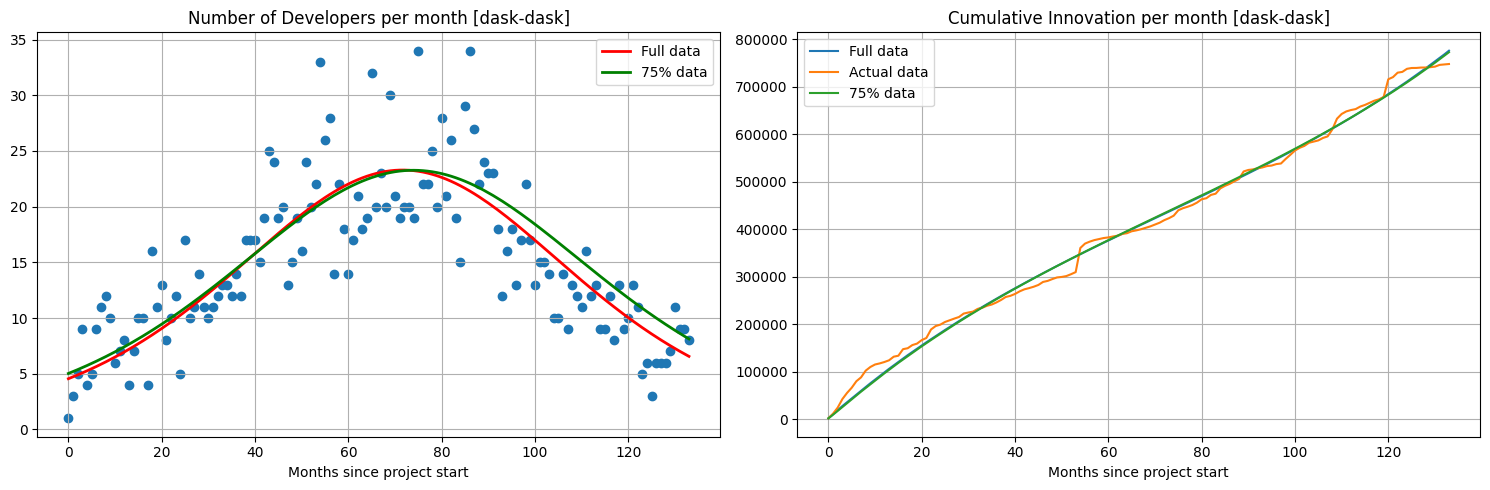

Forecast Length = 65


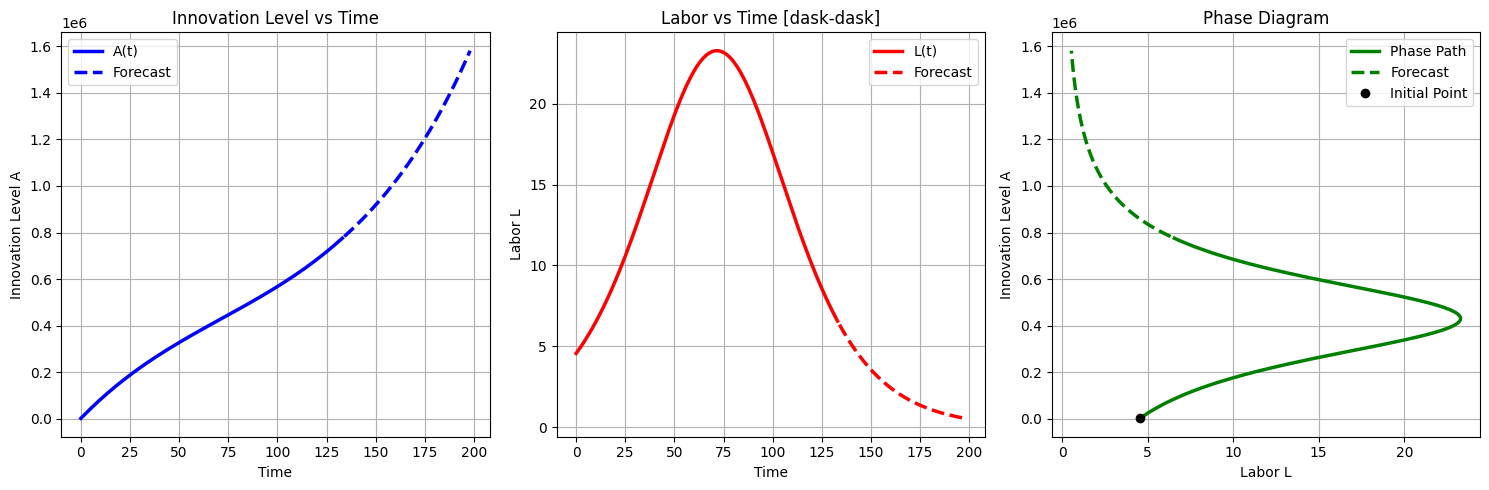

Total Lifecycle Innovation = 1580816.4083157578
Project: huggingface-transformers
Number of periods: 88
R² = 0.681678
b0 = 29.762653 ± 4.763024 | t-stat = 6.2487
b1 = 0.028477 ± 0.003680 | t-stat = 7.7392
b2 = -2.378373e-06 ± 5.481981e-07 | t-stat = -4.3385
p: 0.002299987395869375 q: 0.03077699347551261 m: 12940.354949204473 t: 88 T: 284.6720531746458 yrs: 16.389337764553815
Project: huggingface-transformers
Number of periods: 66
R² = 0.643889
b0 = 26.784623 ± 5.158419 | t-stat = 5.1924
b1 = 0.035121 ± 0.006216 | t-stat = 5.6497
b2 = -4.141702e-06 ± 1.452625e-06 | t-stat = -2.8512
p1: 0.002916443022355845 q1: 0.038037405436299736 m1: 9184.00365379549 t1: 66 T1: 226.17320794445303 yrs1: 13.34776732870442
NObs= 88
Number of periods: 88
R² = 0.681678
b0 = 29.762653 ± 4.763024 | t-stat = 6.2487
b1 = 0.028477 ± 0.003680 | t-stat = 7.7392
b2 = -2.378373e-06 ± 5.481981e-07 | t-stat = -4.3385
Initial obj fn value = 2557786.4431497524
Final obj fn value = 188767.07744291902 ( 7.38 % )
Solution 

/var/folders/39/_tms02415nx6vyczz78csvl80000gr/T/ipykernel_48773/4179859353.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, tmp])
/var/folders/39/_tms02415nx6vyczz78csvl80000gr/T/ipykernel_48773/4179859353.py:78: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results2 = pd.concat([results2, tmp2])


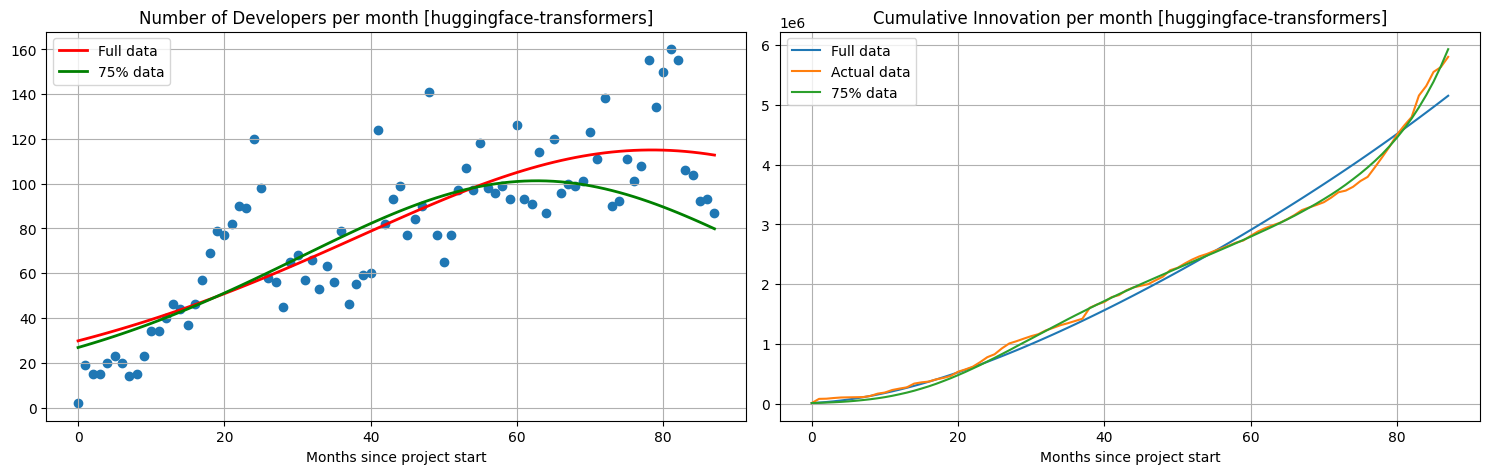

Forecast Length = 196


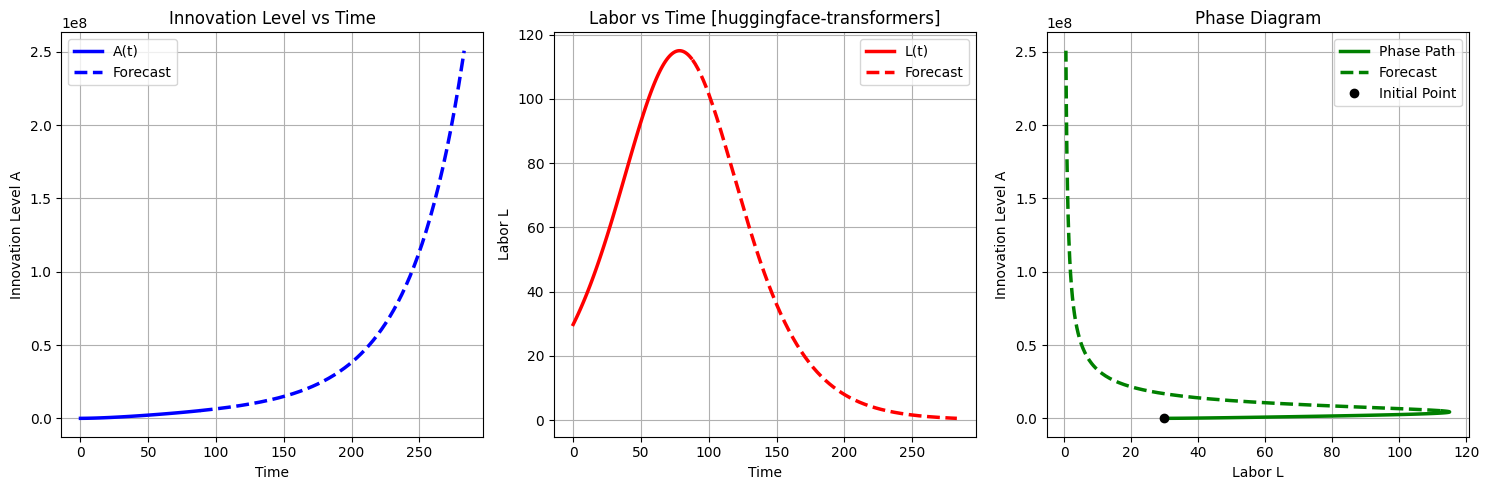

Total Lifecycle Innovation = 250800129.42032227
Project: jupyterlab-jupyterlab
Number of periods: 127
R² = 0.463826
b0 = 10.089616 ± 1.246325 | t-stat = 8.0955
b1 = 0.026495 ± 0.002571 | t-stat = 10.3063
b2 = -1.066320e-05 ± 1.042757e-06 | t-stat = -10.2260
p: 0.003577598548142592 q: 0.030072565028045325 m: 2820.2203697974105 t: 127 T: 222.2224572844254 yrs: 7.935204773702115
Project: jupyterlab-jupyterlab
Number of periods: 95
R² = 0.512410
b0 = 8.374290 ± 1.413585 | t-stat = 5.9242
b1 = 0.035288 ± 0.003929 | t-stat = 8.9803
b2 = -1.590112e-05 ± 2.082982e-06 | t-stat = -7.6338
p1: 0.0034384816199338896 q1: 0.03872657291072849 m1: 2435.4617092370204 t1: 95 T1: 185.5193312048716 yrs1: 7.543277600405967
NObs= 127
Number of periods: 127
R² = 0.463826
b0 = 10.089616 ± 1.246325 | t-stat = 8.0955
b1 = 0.026495 ± 0.002571 | t-stat = 10.3063
b2 = -1.066320e-05 ± 1.042757e-06 | t-stat = -10.2260
Initial obj fn value = 2625758.7505660285
Final obj fn value = 84561.48931139373 ( 3.22 % )
Solution

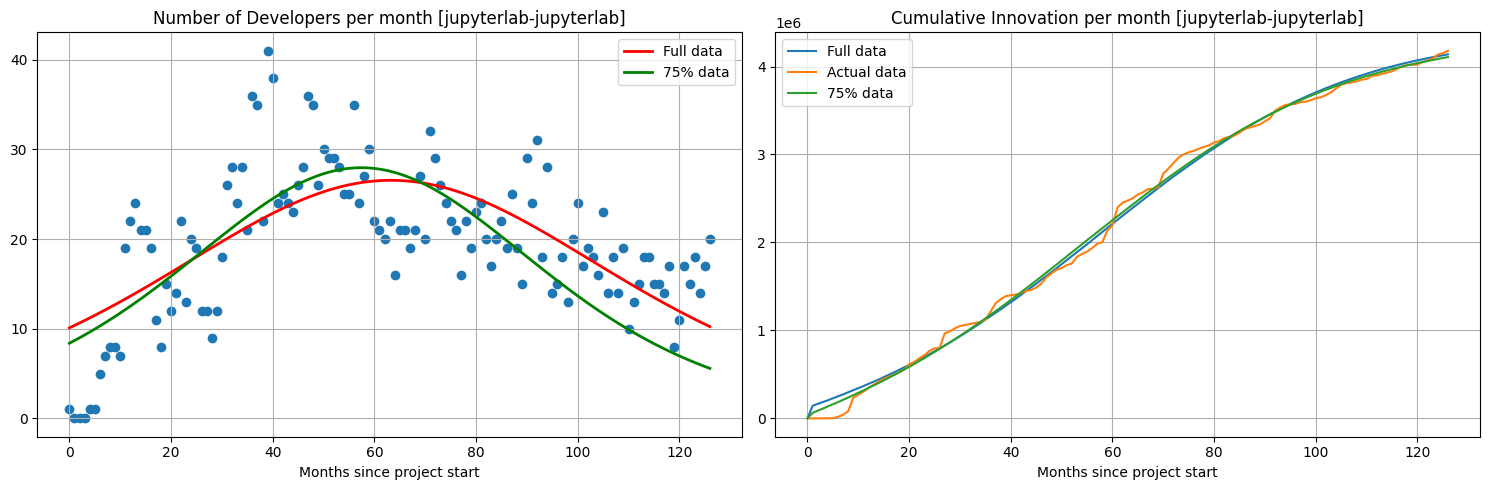

Forecast Length = 95


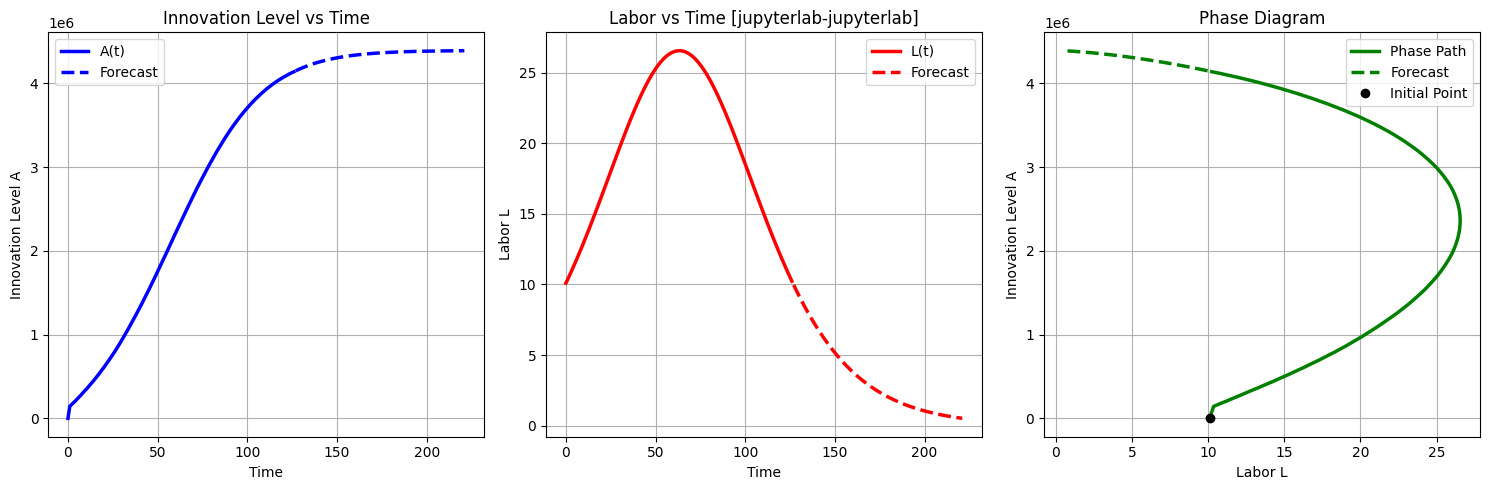

Total Lifecycle Innovation = 4388523.208278991
Project: kubernetes-kubernetes
Number of periods: 140
R² = 0.619899
b0 = 110.831610 ± 6.389113 | t-stat = 17.3469
b1 = 0.017691 ± 0.001450 | t-stat = 12.2014
b2 = -9.355498e-07 ± 6.702084e-08 | t-stat = -13.9591
p: 0.004642703721547291 q: 0.022333644313307408 m: 23872.212576056132 t: 140 T: 330.6303560327003 yrs: 15.885863002725026
Project: kubernetes-kubernetes
Number of periods: 105
R² = 0.684975
b0 = 93.792334 ± 6.156212 | t-stat = 15.2354
b1 = 0.026364 ± 0.001782 | t-stat = 14.7955
b2 = -1.515255e-06 ± 1.027564e-07 | t-stat = -14.7461
p1: 0.004591132510638632 q1: 0.03095517148649462 m1: 20429.01921463029 t1: 105 T1: 262.37464600007513 yrs1: 13.114553833339594
NObs= 140
Number of periods: 140
R² = 0.619899
b0 = 110.831610 ± 6.389113 | t-stat = 17.3469
b1 = 0.017691 ± 0.001450 | t-stat = 12.2014
b2 = -9.355498e-07 ± 6.702084e-08 | t-stat = -13.9591
Initial obj fn value = 35416146.89651372
Final obj fn value = 4593657.389744019 ( 12.97 % 

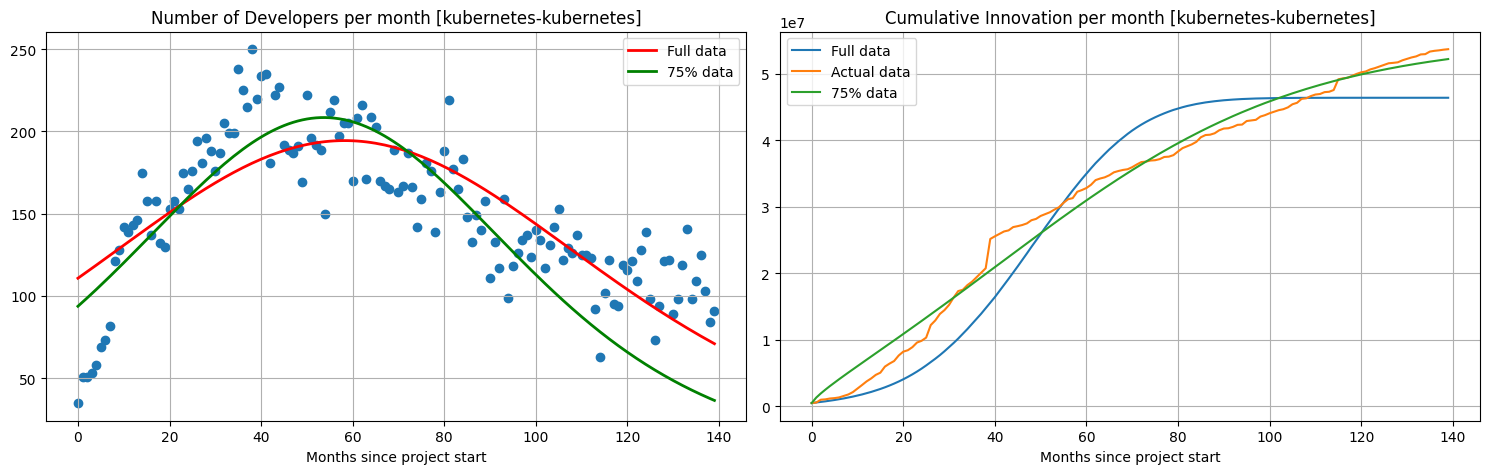

Forecast Length = 190


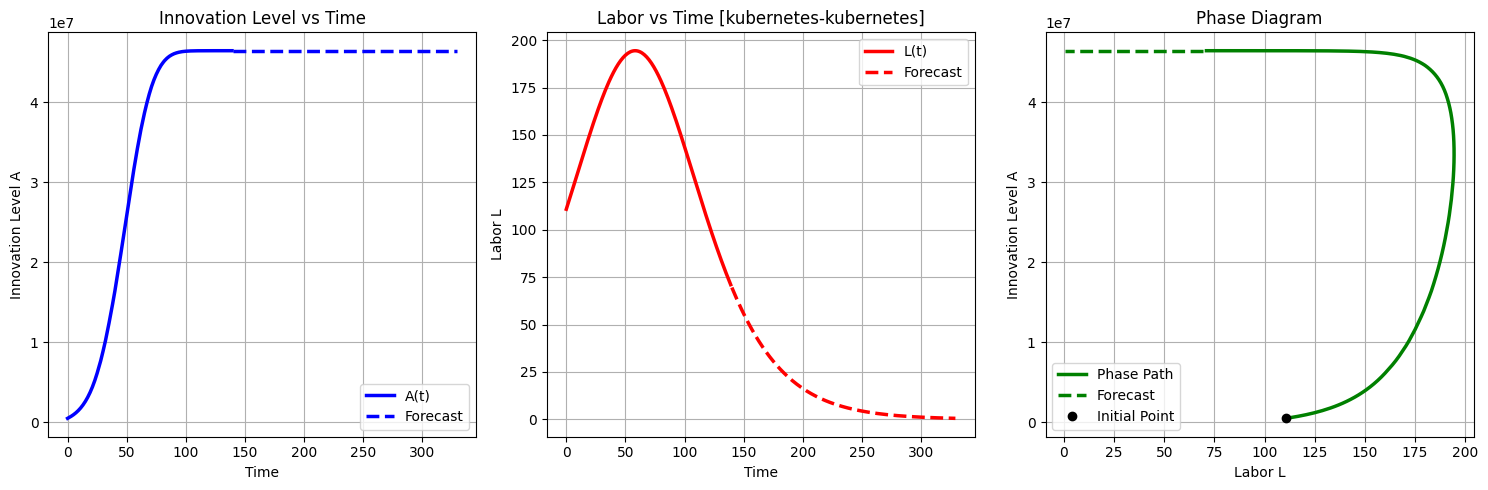

Total Lifecycle Innovation = 46414264.113586
Project: langchain-ai-langchain
Number of periods: 40
R² = 0.746970
b0 = 70.711373 ± 16.451112 | t-stat = 4.2983
b1 = 0.133325 ± 0.015375 | t-stat = 8.6713
b2 = -2.788140e-05 ± 2.838252e-06 | t-stat = -9.8234
p: 0.013433781560190629 q: 0.14675927992516863 m: 5263.698269608321 t: 40 T: 61.84962369260224 yrs: 1.8208019743835202
Project: langchain-ai-langchain
Number of periods: 30
R² = 0.677919
b0 = 62.555523 ± 18.661548 | t-stat = 3.3521
b1 = 0.153946 ± 0.020670 | t-stat = 7.4477
b2 = -3.328846e-05 ± 4.439088e-06 | t-stat = -7.4989
p1: 0.012510036422724424 q1: 0.1664565082223122 m1: 5000.426936530903 t1: 30 T1: 56.71169939586472 yrs1: 2.2259749496553933
NObs= 40
Number of periods: 40
R² = 0.746970
b0 = 70.711373 ± 16.451112 | t-stat = 4.2983
b1 = 0.133325 ± 0.015375 | t-stat = 8.6713
b2 = -2.788140e-05 ± 2.838252e-06 | t-stat = -9.8234
Initial obj fn value = 4192867.5089195184
Final obj fn value = 239270.39861997182 ( 5.71 % )
Solution succes

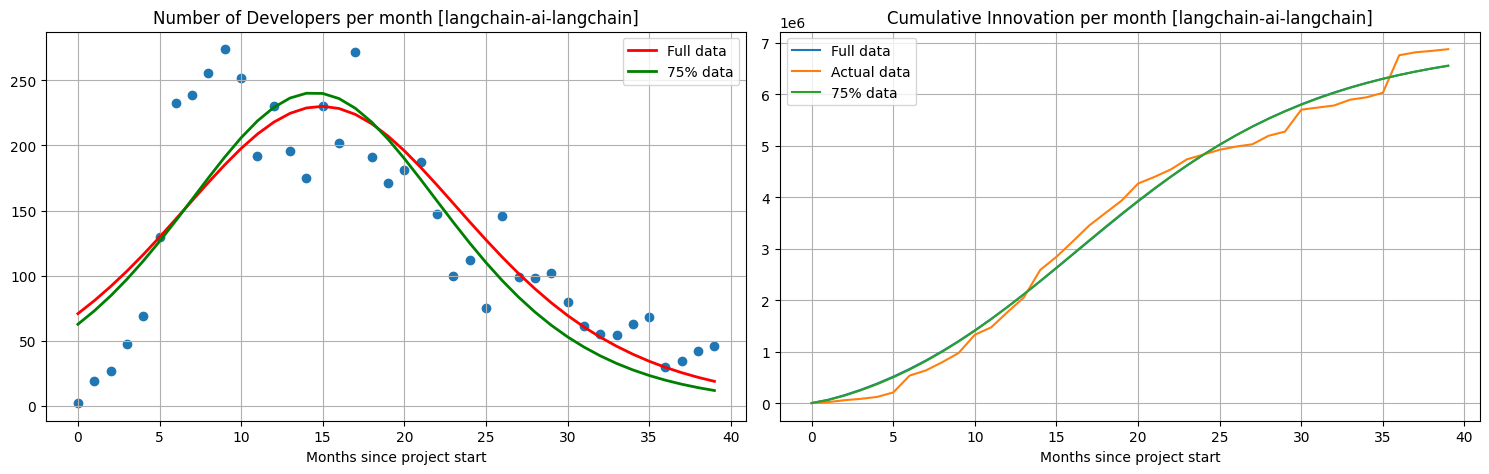

Forecast Length = 21


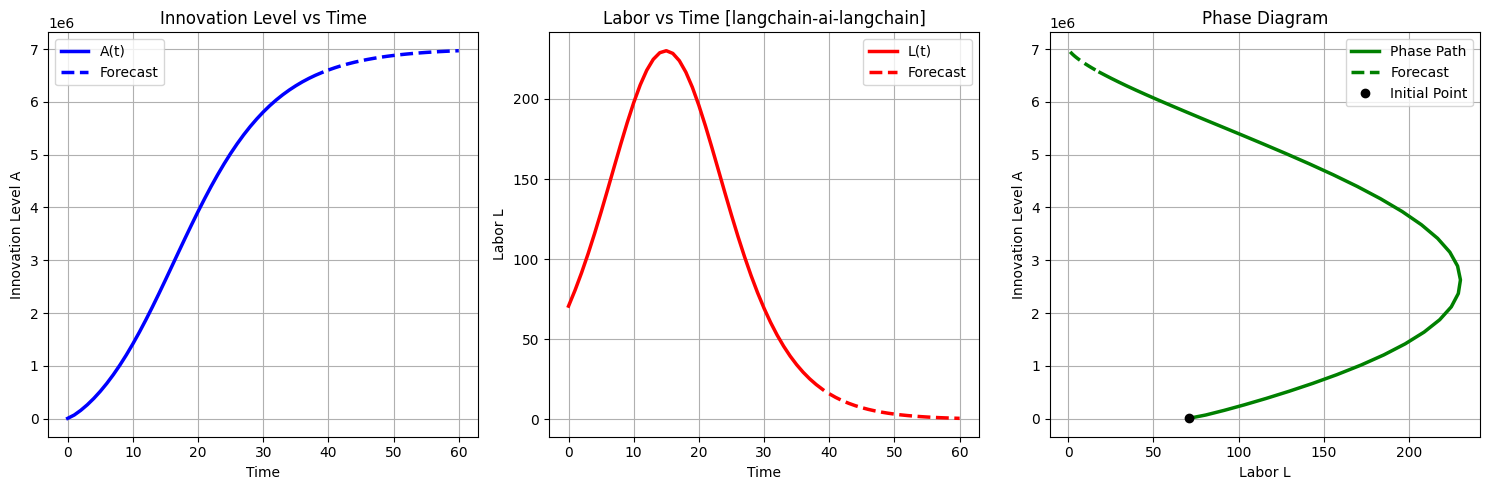

Total Lifecycle Innovation = 6969044.3751748195
Project: microsoft-DeepSpeed
Number of periods: 73
R² = 0.675286
b0 = 2.948832 ± 1.393103 | t-stat = 2.1167
b1 = 0.068058 ± 0.005869 | t-stat = 11.5969
b2 = -4.678673e-05 ± 4.462222e-06 | t-stat = -10.4851
p: 0.0019701647644434508 q: 0.07002775506245884 m: 1496.7439993002959 t: 73 T: 124.48288929867086 yrs: 4.290240774889238
Project: microsoft-DeepSpeed
Number of periods: 54
R² = 0.703263
b0 = 3.925566 ± 1.688649 | t-stat = 2.3247
b1 = 0.059013 ± 0.009613 | t-stat = 6.1392
b2 = -3.551055e-05 ± 1.012824e-05 | t-stat = -3.5061
p1: 0.0022744996114909175 q1: 0.06128777691400675 m1: 1725.9031533858054 t1: 54 T1: 137.06762056540833 yrs1: 6.9223017137840275
NObs= 73
Number of periods: 73
R² = 0.675286
b0 = 2.948832 ± 1.393103 | t-stat = 2.1167
b1 = 0.068058 ± 0.005869 | t-stat = 11.5969
b2 = -4.678673e-05 ± 4.462222e-06 | t-stat = -10.4851
Initial obj fn value = 361052.4227604903
Final obj fn value = 24005.236059845447 ( 6.65 % )
Solution succes

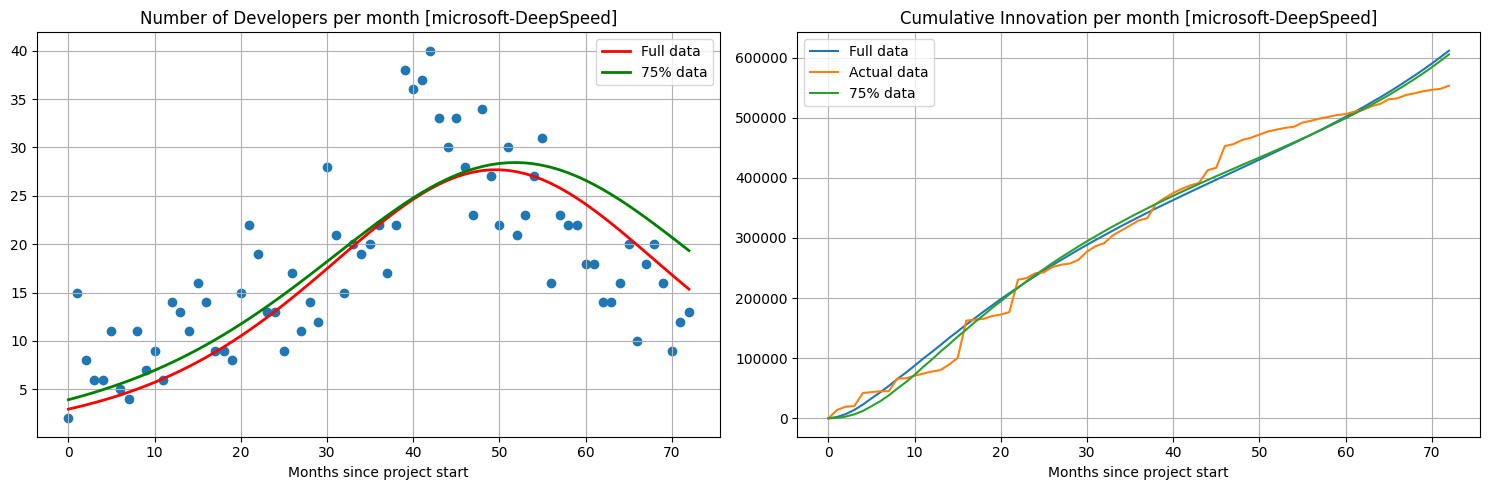

Forecast Length = 51


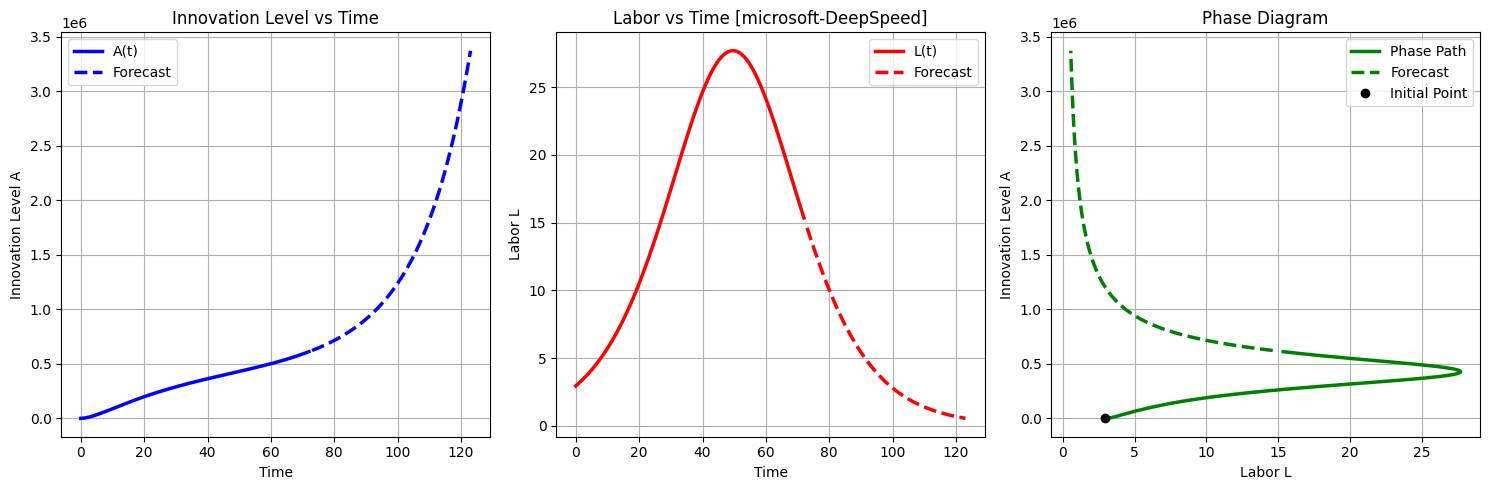

Total Lifecycle Innovation = 3371564.832979387
Project: numpy-numpy
Number of periods: 290
R² = 0.878091
b0 = 1.777151 ± 0.596772 | t-stat = 2.9779
b1 = 0.017164 ± 0.000624 | t-stat = 27.4858
b2 = -1.775518e-06 ± 1.079346e-07 | t-stat = -16.4499
p: 0.00018190601656484885 q: 0.017346115834259067 m: 9769.609119037801 t: 290 T: 593.2492693159464 yrs: 25.270772442995536
Project: numpy-numpy
Number of periods: 217
R² = 0.855707
b0 = 1.824825 ± 0.571899 | t-stat = 3.1908
b1 = 0.017708 ± 0.001155 | t-stat = 15.3287
b2 = -2.261923e-06 ± 3.935080e-07 | t-stat = -5.7481
p1: 0.00023010677290205743 q1: 0.01793782375258611 m1: 7930.341608949184 t1: 217 T1: 551.8230496988027 yrs1: 27.90192080823356
NObs= 290
Number of periods: 290
R² = 0.878091
b0 = 1.777151 ± 0.596772 | t-stat = 2.9779
b1 = 0.017164 ± 0.000624 | t-stat = 27.4858
b2 = -1.775518e-06 ± 1.079346e-07 | t-stat = -16.4499
Initial obj fn value = 3461691.0148726245
Final obj fn value = 143791.50200319808 ( 4.15 % )
Solution success: True
Be

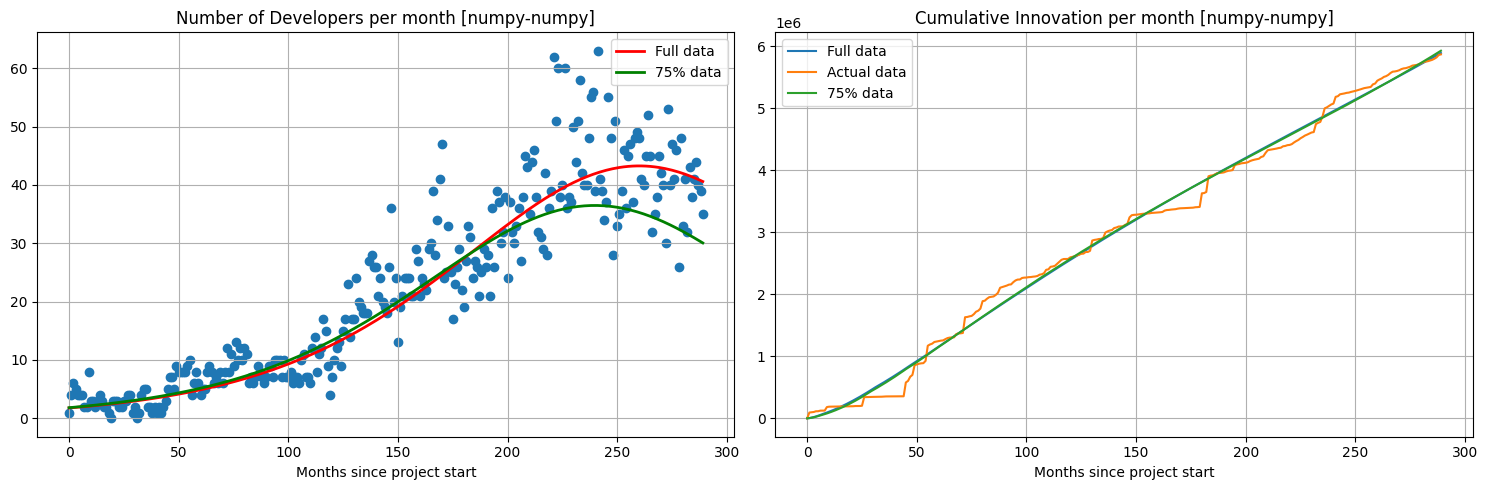

Forecast Length = 303


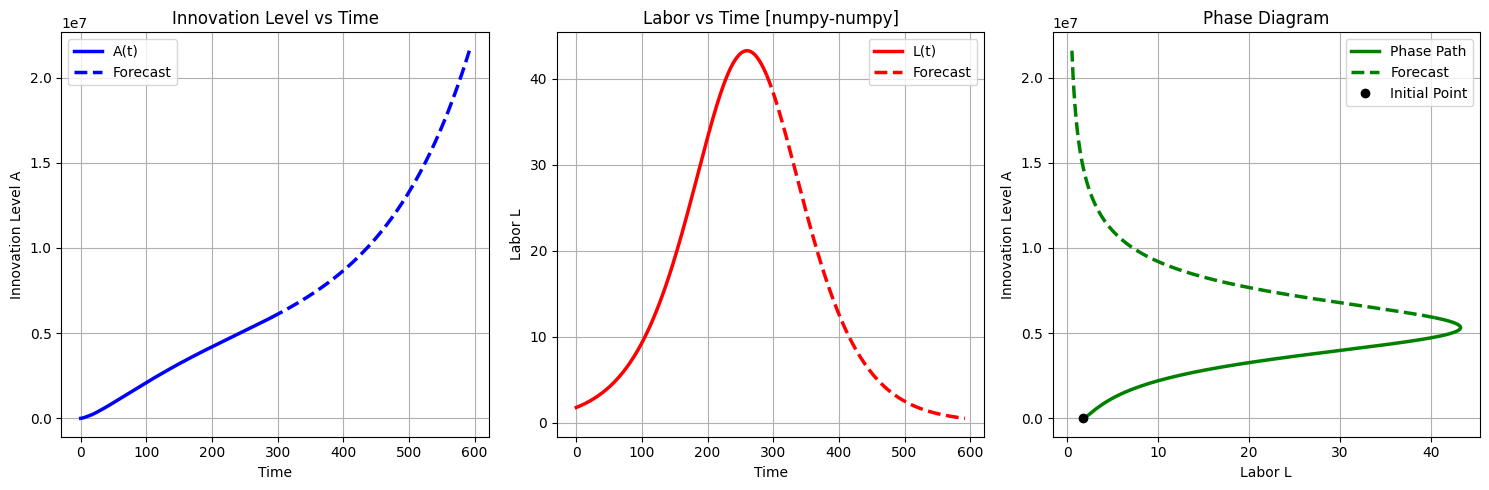

Total Lifecycle Innovation = 21572650.59223943
Project: pandas-dev-pandas
Number of periods: 199
R² = 0.719817
b0 = 7.916946 ± 1.725657 | t-stat = 4.5878
b1 = 0.026022 ± 0.001328 | t-stat = 19.6020
b2 = -2.842782e-06 ± 1.770313e-07 | t-stat = -16.0581
p: 0.0008378949010358415 q: 0.026860353435202933 m: 9448.615102836156 t: 199 T: 352.1847454396922 yrs: 12.765395453307685
Project: pandas-dev-pandas
Number of periods: 149
R² = 0.771355
b0 = 6.279731 ± 1.825309 | t-stat = 3.4404
b1 = 0.029510 ± 0.002112 | t-stat = 13.9703
b2 = -3.533816e-06 ± 4.223945e-07 | t-stat = -8.3662
p1: 0.0007337449510737746 q1: 0.030244043024273304 m1: 8558.465416315881 t1: 149 T1: 323.2157836265854 yrs1: 14.517981968882117
NObs= 199
Number of periods: 199
R² = 0.719817
b0 = 7.916946 ± 1.725657 | t-stat = 4.5878
b1 = 0.026022 ± 0.001328 | t-stat = 19.6020
b2 = -2.842782e-06 ± 1.770313e-07 | t-stat = -16.0581
Initial obj fn value = 2923272.5623398377
Final obj fn value = 68525.99300993136 ( 2.34 % )
Solution succe

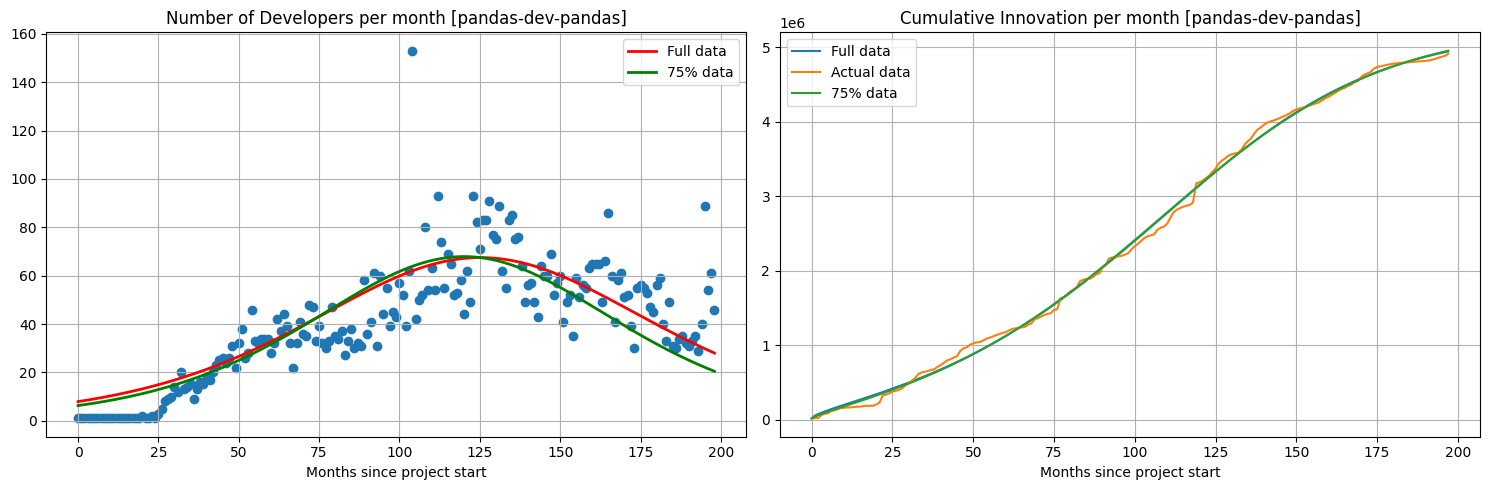

Forecast Length = 153


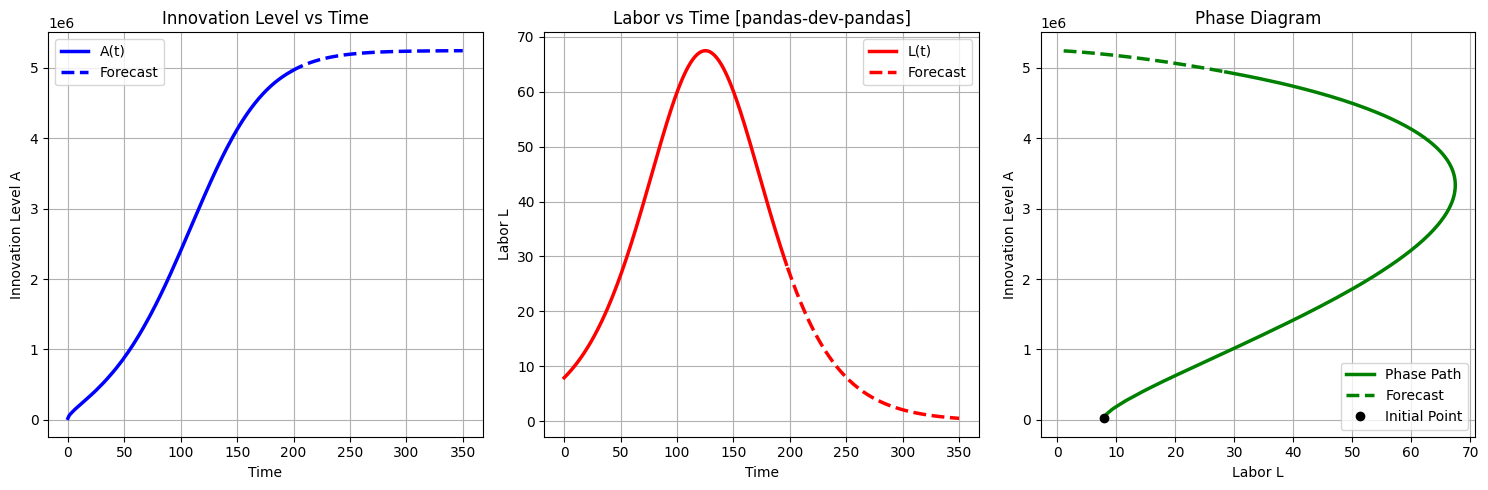

Total Lifecycle Innovation = 5242866.982643969
Project: pytorch-pytorch
Number of periods: 169
R² = 0.923692
b0 = 22.079469 ± 3.305296 | t-stat = 6.6800
b1 = 0.028665 ± 0.001105 | t-stat = 25.9354
b2 = -8.480556e-07 ± 5.981407e-08 | t-stat = -14.1782
p: 0.0006389789788381331 q: 0.029303965478040542 m: 34554.29690436435 t: 169 T: 383.4360284126258 yrs: 17.86966903438548
Project: pytorch-pytorch
Number of periods: 126
R² = 0.933811
b0 = 9.426009 ± 2.717823 | t-stat = 3.4682
b1 = 0.048376 ± 0.001978 | t-stat = 24.4575
b2 = -2.941663e-06 ± 2.138845e-07 | t-stat = -13.7535
p1: 0.0005665502257536869 q1: 0.04894207499764911 m1: 16637.55246784213 t1: 126 T1: 239.87924507863534 yrs1: 9.489937089886277
NObs= 169
Number of periods: 169
R² = 0.923692
b0 = 22.079469 ± 3.305296 | t-stat = 6.6800
b1 = 0.028665 ± 0.001105 | t-stat = 25.9354
b2 = -8.480556e-07 ± 5.981407e-08 | t-stat = -14.1782
Initial obj fn value = 11397365.614337157
Final obj fn value = 439895.32049233094 ( 3.86 % )
Solution success

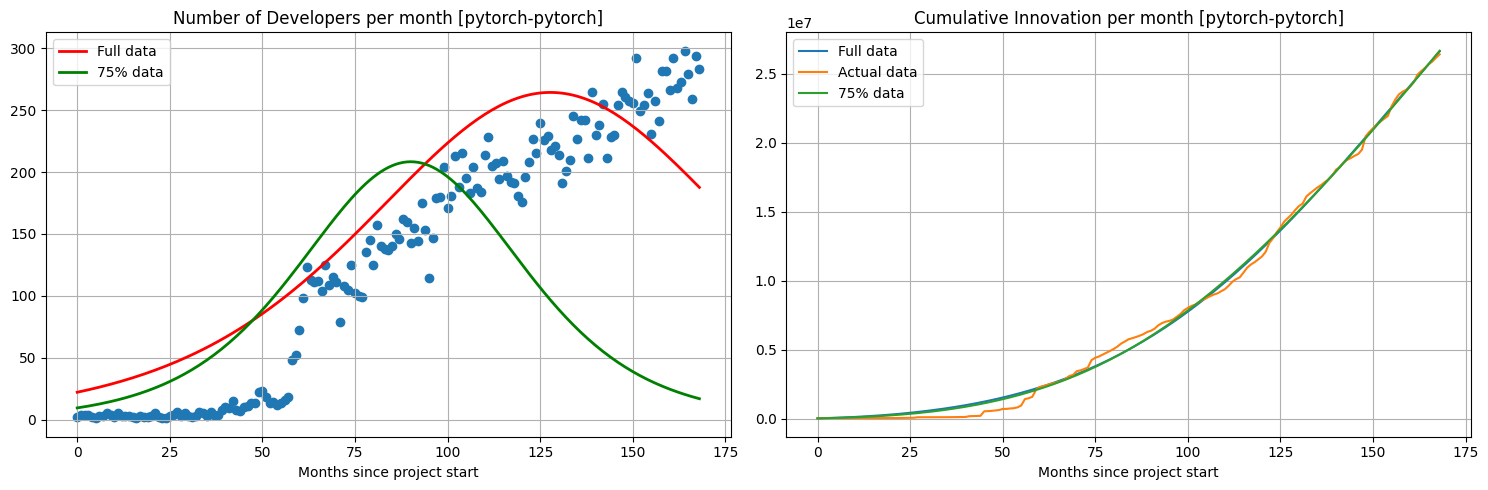

Forecast Length = 214


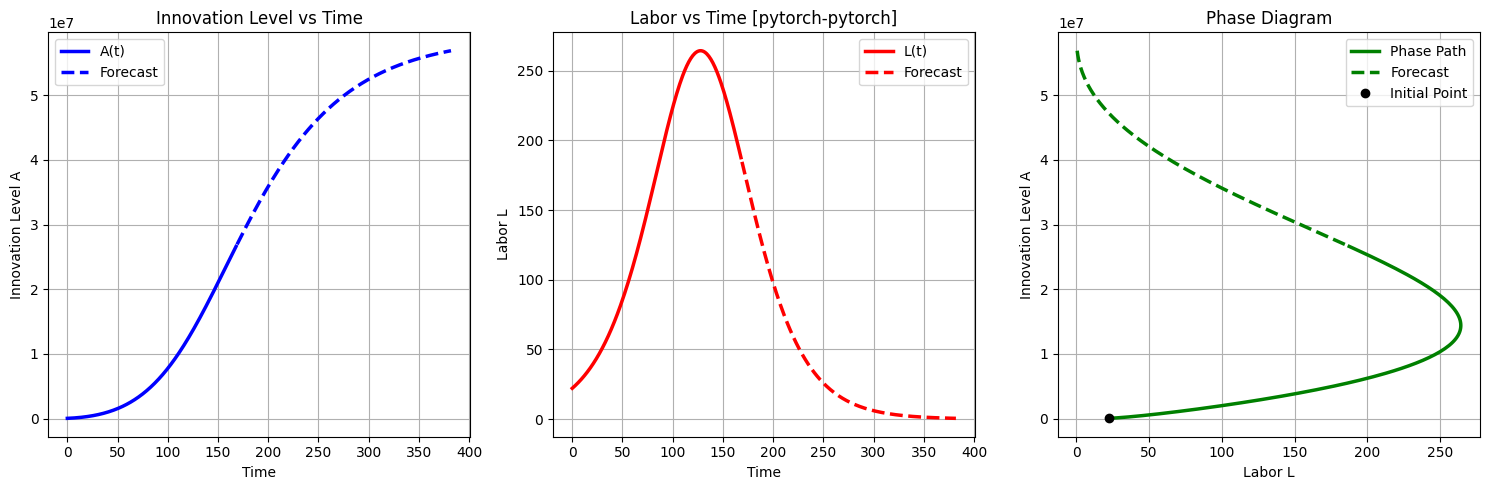

Total Lifecycle Innovation = 56880089.940701455
Project: vllm-project-vllm
Number of periods: 36
R² = 0.972371
b0 = 14.953358 ± 4.991659 | t-stat = 2.9957
b1 = 0.109798 ± 0.007435 | t-stat = 14.7671
b2 = -9.001882e-06 ± 1.841692e-06 | t-stat = -4.8878
p: 0.001212573286998195 q: 0.11101049307884714 m: 12331.921161516446 t: 36 T: 110.96520409819804 yrs: 6.247100341516504
Project: vllm-project-vllm
Number of periods: 27
R² = 0.941958
b0 = 13.922436 ± 4.942046 | t-stat = 2.8171
b1 = 0.119523 ± 0.016028 | t-stat = 7.4571
b2 = -1.534246e-05 ± 8.798674e-06 | t-stat = -1.7437
p1: 0.0017611900406641744 q1: 0.12128414686391342 m1: 7905.129993563555 t1: 27 T1: 96.05208356500029 yrs1: 5.754340297083357
NObs= 36
Number of periods: 36
R² = 0.972371
b0 = 14.953358 ± 4.991659 | t-stat = 2.9957
b1 = 0.109798 ± 0.007435 | t-stat = 14.7671
b2 = -9.001882e-06 ± 1.841692e-06 | t-stat = -4.8878
Initial obj fn value = 1085892.398105838
Final obj fn value = 41170.1871324905 ( 3.79 % )
Solution success: True
B

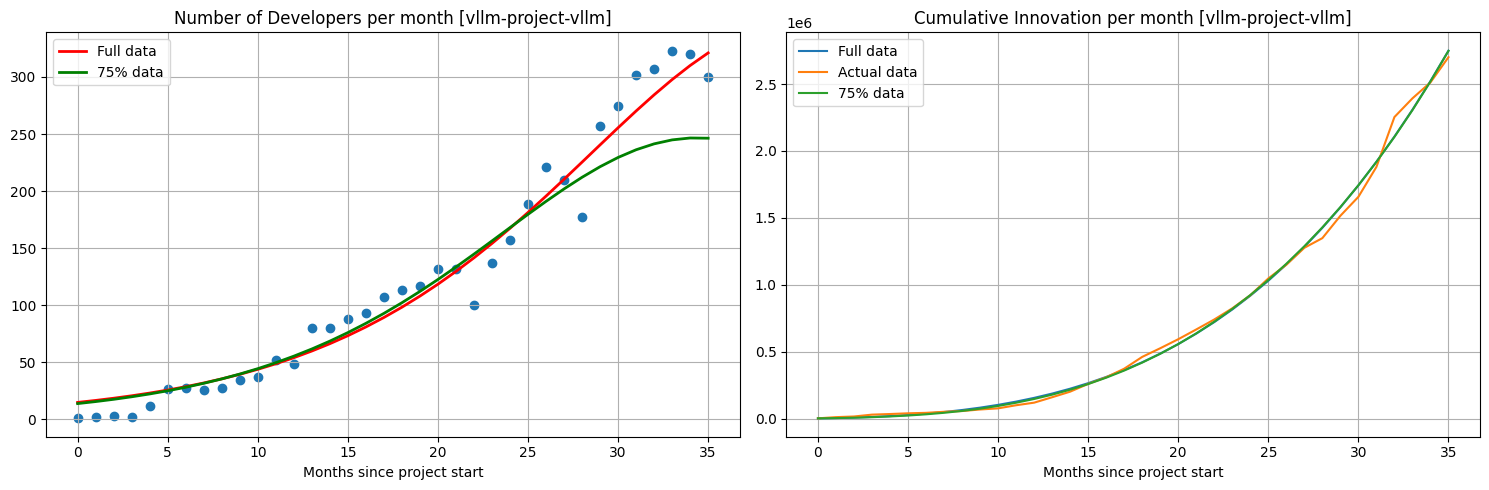

Forecast Length = 74


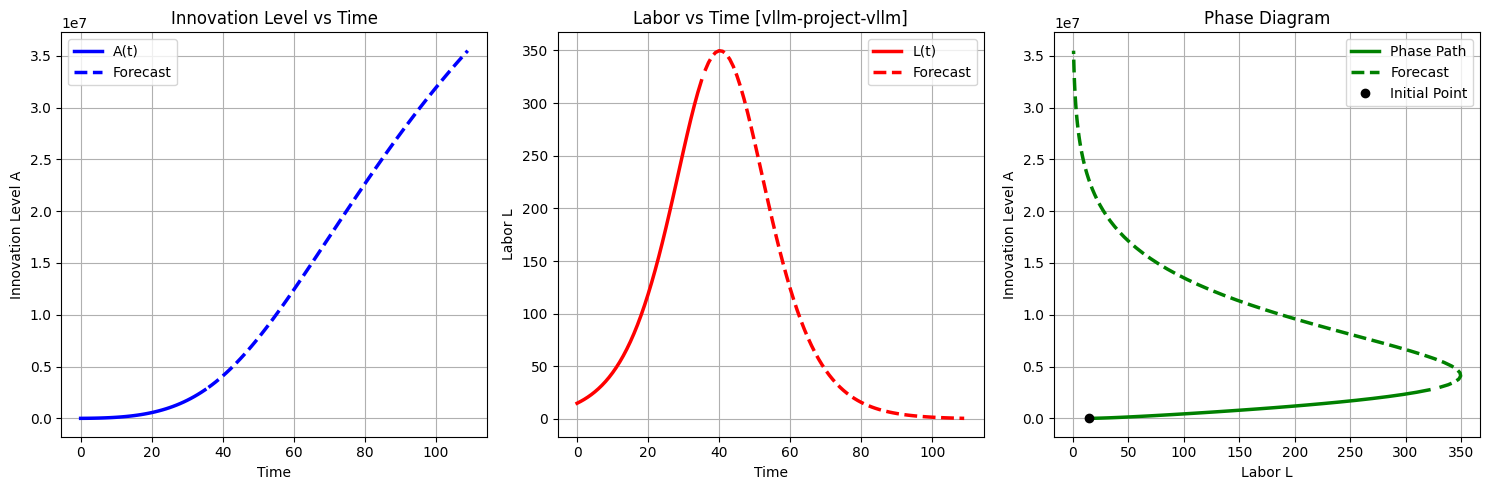

Total Lifecycle Innovation = 35493054.75243813
ALL DONE


In [5]:
# Redo the above to make a single plot with subplots for 5 repos at a time, with both developer engagement and innovation forecasts.
results = pd.DataFrame(columns=['p','q','m','t','T','yrs','p1','q1','m1','t1','T1','yrs1','currDev','currInn','lifeInn','currValue','lifeValue','ratio'])
results2 = pd.DataFrame(columns=['gamma','lambda','phi'])

for repo_string in repo_string_list:
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # Fit Developer Engagement
    p, q, m, t, T, yrs = get_developer_params(repo_string, init_life_fraction=1.0)
    print("p:", p, "q:", q, "m:", m, "t:", t, "T:", T, "yrs:", yrs)
    p1, q1, m1, t1, T1, yrs1 = get_developer_params(repo_string, init_life_fraction=0.75)
    print("p1:", p1, "q1:", q1, "m1:", m1, "t1:", t1, "T1:", T1, "yrs1:", yrs1)

    # Plot Developer engagement from full data and 75% data
    df = pd.read_csv("data/" + repo_string + "-monthly.csv")
    tt = np.arange(len(df))
    axs[0].scatter(tt, df['contributors'])
    axs[0].plot(tt, bass(p, q, tt)[0]*m, color='red', linewidth=2, label='Full data')
    axs[0].plot(tt, bass(p1, q1, tt)[0]*m1, color='green', linewidth=2, label='75% data')
    axs[0].set_title(f"Number of Developers per month [{repo_string}]")
    axs[0].set_xlabel("Months since project start")
    axs[0].legend()
    axs[0].grid(True)
    
    # INNOVATION
    
    # Fit Innovation
    gamma, lam, phi, df = get_innovation_params(repo_string, init_life_fraction=1.0)
    print("gamma:", gamma, "lam:", lam, "phi:", phi)
    gamma1, lam1, phi1, df1 = get_innovation_params(repo_string, init_life_fraction=0.75)
    print("gamma1:", gamma1, "lam1:", lam1, "phi1:", phi1)
    
    # Plot Innovation
    tt = np.arange(len(df))
    L = forecastL(p, q, m, tt)
    A = forecastA(gamma, lam, phi, tt, df['cumInnovation'][0], df["contributors"], L)
    L1 = forecastL(p1, q1, m1, tt)
    A1 = forecastA(gamma1, lam1, phi1, tt, df['cumInnovation'][0], df1["contributors"], L1)

    axs[1].plot(tt, A, label='Full data')
    axs[1].plot(tt, df['cumInnovation'], label='Actual data')
    axs[1].plot(tt, A1, label='75% data')
    axs[1].set_title(f"Cumulative Innovation per month [{repo_string}]")
    axs[1].set_xlabel("Months since project start")
    axs[1].legend()
    axs[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(f"images/{repo_string}_compare_forecasts.png")
    plt.show()

    # get forecasts
    forecast_length = int(T-t) # for no forecast, set to 1 month
    print("Forecast Length =", forecast_length)
    tt = np.arange(len(df)+forecast_length) # added remaining life to forecast
    L = forecastL(p, q, m, tt)
    A = forecastA(gamma, lam, phi, tt, df['cumInnovation'][0], df['contributors'], L)
    plotForecast(A, L, forecast_length, repo_string) 
    lifetime_innovation = A[-1]
    print("Total Lifecycle Innovation =", lifetime_innovation)

    # Valuation
    dev_time_invested = 0.50 # assume 50% time only on average
    monthly_salary = 10000
    current_innovation = A[t] # current cumulative innovation
    current_dev_months = df['contributors'].sum()
    innov_dev_ratio = current_innovation/current_dev_months
    # E_i = 2.94*(current_innovation/1000)**1.0997
    currValue = monthly_salary*current_dev_months*dev_time_invested
    lifeValue = monthly_salary*(lifetime_innovation/innov_dev_ratio)*dev_time_invested

    # Add to results
    tmp = pd.DataFrame({"p": p, "q": q, "m": m, "t": t, "T": T, "yrs": yrs, "p1": p1, "q1": q1, "m1": m1, "t1": t1, 
                        "T1": T1, "yrs1": yrs1, "currDev": current_dev_months, "currInn": current_innovation, "lifeInn": lifetime_innovation, 
                        "currValue": currValue, "lifeValue": lifeValue, "ratio": innov_dev_ratio}, index=[repo_string])
    results = pd.concat([results, tmp])
    tmp2 = pd.DataFrame({'gamma':gamma,'lambda':lam,'phi':phi}, index=[repo_string])
    results2 = pd.concat([results2, tmp2])

print("ALL DONE")
    

In [6]:
results

,p,q,m,t,T,yrs,p1,q1,m1,t1,T1,yrs1,currDev,currInn,lifeInn,currValue,lifeValue,ratio
dask-dask,0.002096,0.038550,2173.646274,134,199.976834,5.498070,0.002169,0.035689,2317.541967,100,211.740446,9.311704,1938,7.829227e+05,1.580816e+06,9690000.0,1.956529e+07,403.984870
huggingface-transformers,0.002300,0.030777,12940.354949,88,284.672053,16.389338,0.002916,0.038037,9184.003654,66,226.173208,13.347767,6990,5.245359e+06,2.508001e+08,34950000.0,1.671089e+09,750.409039
jupyterlab-jupyterlab,0.003578,0.030073,2820.220370,127,222.222457,7.935205,0.003438,0.038727,2435.461709,95,185.519331,7.543278,2426,4.148582e+06,4.388523e+06,12130000.0,1.283156e+07,1710.050477
kubernetes-kubernetes,0.004643,0.022334,23872.212576,140,330.630356,15.885863,0.004591,0.030955,20429.019215,105,262.374646,13.114554,20949,4.641426e+07,4.641426e+07,104745000.0,1.047450e+08,2215.583563
langchain-ai-langchain,0.013434,0.146759,5263.698270,40,61.849624,1.820802,0.012510,0.166457,5000.426937,30,56.711699,2.225975,5168,6.603561e+06,6.969044e+06,25840000.0,2.727015e+07,1277.778920
microsoft-DeepSpeed,0.001970,0.070028,1496.743999,73,124.482889,4.290241,0.002274,0.061288,1725.903153,54,137.067621,6.922302,1213,6.225391e+05,3.371565e+06,6065000.0,3.284700e+07,513.222677
numpy-numpy,0.000182,0.017346,9769.609119,290,593.249269,25.270772,0.000230,0.017938,7930.341609,217,551.823050,27.901921,5939,5.909455e+06,2.157265e+07,29695000.0,1.084025e+08,995.025327
pandas-dev-pandas,0.000838,0.026860,9448.615103,199,352.184745,12.765395,0.000734,0.030244,8558.465416,149,323.215784,14.517982,8214,4.959362e+06,5.242867e+06,41070000.0,4.341779e+07,603.769458
pytorch-pytorch,0.000639,0.029304,34554.296904,169,383.436028,17.869669,0.000567,0.048942,16637.552468,126,239.879245,9.489937,26430,2.692746e+07,5.688009e+07,132150000.0,2.791464e+08,1018.821669
vllm-project-vllm,0.001213,0.111010,12331.921162,36,110.965204,6.247100,0.001761,0.121284,7905.129994,27,96.052084,5.754340,4465,2.989209e+06,3.549305e+07,22325000.0,2.650810e+08,669.475629


In [7]:
# TABLE III
results1 = results.copy()[['t','T','currDev','currInn','lifeInn','ratio','currValue','lifeValue']]
results1

,t,T,currDev,currInn,lifeInn,ratio,currValue,lifeValue
dask-dask,134,199.976834,1938,7.829227e+05,1.580816e+06,403.984870,9690000.0,1.956529e+07
huggingface-transformers,88,284.672053,6990,5.245359e+06,2.508001e+08,750.409039,34950000.0,1.671089e+09
jupyterlab-jupyterlab,127,222.222457,2426,4.148582e+06,4.388523e+06,1710.050477,12130000.0,1.283156e+07
kubernetes-kubernetes,140,330.630356,20949,4.641426e+07,4.641426e+07,2215.583563,104745000.0,1.047450e+08
langchain-ai-langchain,40,61.849624,5168,6.603561e+06,6.969044e+06,1277.778920,25840000.0,2.727015e+07
microsoft-DeepSpeed,73,124.482889,1213,6.225391e+05,3.371565e+06,513.222677,6065000.0,3.284700e+07
numpy-numpy,290,593.249269,5939,5.909455e+06,2.157265e+07,995.025327,29695000.0,1.084025e+08
pandas-dev-pandas,199,352.184745,8214,4.959362e+06,5.242867e+06,603.769458,41070000.0,4.341779e+07
pytorch-pytorch,169,383.436028,26430,2.692746e+07,5.688009e+07,1018.821669,132150000.0,2.791464e+08
vllm-project-vllm,36,110.965204,4465,2.989209e+06,3.549305e+07,669.475629,22325000.0,2.650810e+08


In [8]:
# Format the last 4 columns in thousands with two decimal places
results1[['T','currDev']] = results1[['T','currDev']].map(lambda x: f'{x:.0f}')
results1[['ratio']] = results1[['ratio']].map(lambda x: f'{x:.2f}')
results1[['currInn', 'lifeInn', 'currValue', 'lifeValue']] = results1[['currInn', 'lifeInn', 'currValue', 'lifeValue']].map(lambda x: f'{x/1000000:.2f}')

# Convert the DataFrame to LaTeX format
latex_code = results1.to_latex(index=True)
print(latex_code)

\begin{tabular}{lllllllll}
\toprule
 & t & T & currDev & currInn & lifeInn & ratio & currValue & lifeValue \\
\midrule
dask-dask & 134 & 200 & 1938 & 0.78 & 1.58 & 403.98 & 9.69 & 19.57 \\
huggingface-transformers & 88 & 285 & 6990 & 5.25 & 250.80 & 750.41 & 34.95 & 1671.09 \\
jupyterlab-jupyterlab & 127 & 222 & 2426 & 4.15 & 4.39 & 1710.05 & 12.13 & 12.83 \\
kubernetes-kubernetes & 140 & 331 & 20949 & 46.41 & 46.41 & 2215.58 & 104.75 & 104.75 \\
langchain-ai-langchain & 40 & 62 & 5168 & 6.60 & 6.97 & 1277.78 & 25.84 & 27.27 \\
microsoft-DeepSpeed & 73 & 124 & 1213 & 0.62 & 3.37 & 513.22 & 6.07 & 32.85 \\
numpy-numpy & 290 & 593 & 5939 & 5.91 & 21.57 & 995.03 & 29.70 & 108.40 \\
pandas-dev-pandas & 199 & 352 & 8214 & 4.96 & 5.24 & 603.77 & 41.07 & 43.42 \\
pytorch-pytorch & 169 & 383 & 26430 & 26.93 & 56.88 & 1018.82 & 132.15 & 279.15 \\
vllm-project-vllm & 36 & 111 & 4465 & 2.99 & 35.49 & 669.48 & 22.32 & 265.08 \\
\bottomrule
\end{tabular}



In [9]:
# TABLE I
results3 = results2.copy()
results3[['lambda','phi']] = results3[['lambda','phi']].map(lambda x: f'{x:.4f}')
results3[['gamma']] = results3[['gamma']].map(lambda x: f'{x:.2f}')
results3

,gamma,lambda,phi
dask-dask,13255.95,-0.3811,0.0111
huggingface-transformers,292.79,-0.4171,0.5017
jupyterlab-jupyterlab,11300.14,1.4304,-0.2231
kubernetes-kubernetes,0.00,12.9150,-1.1730
langchain-ai-langchain,1431.86,0.7093,0.0916
microsoft-DeepSpeed,649.79,-0.6623,0.3490
numpy-numpy,370.42,-0.3206,0.3318
pandas-dev-pandas,601657.05,1.3005,-0.5523
pytorch-pytorch,21.03,0.4524,0.4228
vllm-project-vllm,13.30,0.1723,0.5940


In [10]:
# Convert the DataFrame to LaTeX format
latex_code = results3.to_latex(index=True)
print(latex_code)

\begin{tabular}{llll}
\toprule
 & gamma & lambda & phi \\
\midrule
dask-dask & 13255.95 & -0.3811 & 0.0111 \\
huggingface-transformers & 292.79 & -0.4171 & 0.5017 \\
jupyterlab-jupyterlab & 11300.14 & 1.4304 & -0.2231 \\
kubernetes-kubernetes & 0.00 & 12.9150 & -1.1730 \\
langchain-ai-langchain & 1431.86 & 0.7093 & 0.0916 \\
microsoft-DeepSpeed & 649.79 & -0.6623 & 0.3490 \\
numpy-numpy & 370.42 & -0.3206 & 0.3318 \\
pandas-dev-pandas & 601657.05 & 1.3005 & -0.5523 \\
pytorch-pytorch & 21.03 & 0.4524 & 0.4228 \\
vllm-project-vllm & 13.30 & 0.1723 & 0.5940 \\
\bottomrule
\end{tabular}

